In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

In [2]:
import warnings; warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
from pathlib import Path
import data as dt, models as md, backtest as bt
output_dir = Path("../Outputs")
output_dir.mkdir(exist_ok = True)
print("Imports OK")

Imports OK


In [3]:
stocks_returns, macro_returns, prices = dt.load_data()
stocks_returns = stocks_returns[stocks_returns.index >= dt.test_start]
macro_returns = macro_returns[macro_returns.index >= dt.test_start]
print(f"Running validation period only: "f"{stocks_returns.index[0].date()} → "f"{stocks_returns.index[-1].date()}")
best_window = 180
zscore_window = 45
n_components = md.n_components
covs = md.rolling_covariances(stocks_returns, window = best_window, use_ledoit_wolf = True)
_, residuals, _, _, _ = md.compute_factor_model(stocks_returns, covs ,n_components)
pc1 = md.compute_pc1_concentration(covs)
zscores = md.compute_rolling_zscore(residuals, window = zscore_window).dropna()

Stocks: 20 tickers
Macro columns: ['SPY', 'Brent', 'VIX']
Dates: 2336 trading days
Range: 2017-04-07 -> 2026-07-30
Running validation period only: 2022-01-03 → 2026-07-30


In [4]:
print("Signal Generation Sanity Check")
print(f"Entry threshold: {bt.entry_threshold}")
print(f"Exit threshold: {bt.exit_threshold}")
print(f"Z-score max: {zscores.abs().max().max():.3f}")
print(f"Z-score 95th pct: {zscores.abs().quantile(0.95).mean():.3f}")
pct_above = (zscores.abs() > bt.entry_threshold).mean().mean()
print(f"% days above threshold: {pct_above:.2%}")
if pct_above < 0.01:
    print("WARNING: < 1% of days generate signals — lower threshold or remove EMA")
elif pct_above > 0.20:
    print("WARNING: > 20% of days generate signals — raise threshold")
else:
    print("OK: signal frequency in acceptable range")

Signal Generation Sanity Check
Entry threshold: 2.25
Exit threshold: 0.5
Z-score max: 5.978
Z-score 95th pct: 1.996
% days above threshold: 3.32%
OK: signal frequency in acceptable range


In [5]:
signals = bt.generate_signals(zscores,
                              entry = bt.entry_threshold,
                              exit_ = bt.exit_threshold,
                              top_n = bt.top_n,
                              min_hold = bt.min_hold_days,
                              momentum = True,
                             )
active = (signals != 0).any(axis=1)
print(f"Active days: {active.sum()} / {len(signals)} ({active.mean():.1%})")
print(f"\nSignal value counts:")
print(signals.stack().value_counts())
signals.head()

Active days: 915 / 954 (95.9%)

Signal value counts:
 0.0    16242
-1.0     1457
 1.0     1381
Name: count, dtype: int64


,DAL,UAL,AAL,LUV,ALK,JBLU,UNP,CSX,NSC,CP,CNI,UPS,FDX,JBHT,ODFL,KNX,SAIA,SNDR,CHRW,EXPD
2022-10-04,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2022-10-05,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2022-10-06,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2022-10-07,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
2022-10-10,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0


In [6]:
holding_periods = []
for col in signals.columns:
    s = signals[col]
    in_pos = False
    count = 0
    for val in s:
        if val != 0:
            count += 1
            in_pos = True
        elif in_pos:
            holding_periods.append(count)
            count = 0
            in_pos = False
    if in_pos and count > 0:
        holding_periods.append(count)

if len(holding_periods) == 0:
    print("No completed positions found.")
    print("Either no signals fired or all positions still open.")
else:
    holding_s = pd.Series(holding_periods)
    print(f"Holding period distribution:")
    print(f"Min: {holding_s.min():.0f} days (should be ≥ 5)")
    print(f"Median: {holding_s.median():.0f} days")
    print(f"Mean: {holding_s.mean():.1f} days")
    print(f"Max: {holding_s.max():.0f} days")
    print(f"Positions shorter than 5 days: {(holding_s < 5).sum()}")

Holding period distribution:
Min: 1 days (should be ≥ 5)
Median: 6 days
Mean: 7.1 days
Max: 19 days
Positions shorter than 5 days: 166


In [7]:
active_days = signals[signals.abs().sum(axis = 1) > 0]
positions_per_day = signals.abs().sum(axis = 1)
print(f"Position count distribution:")
print(positions_per_day[positions_per_day > 0].value_counts().sort_index())

Position count distribution:
1.0     71
2.0    162
3.0    285
4.0    397
Name: count, dtype: int64


In [8]:
rolling_q95 = zscores.abs().rolling(45).quantile(0.95)
print("Rolling 95th percentile of |z-scores|:")
print(rolling_q95.describe().round(3))
print(f"\nFixed threshold 2.25 corresponds to approx the "
      f"{(zscores.abs() > 2.25).mean().mean()*100:.1f}th percentile of your data")

Rolling 95th percentile of |z-scores|:
           DAL      UAL      AAL      LUV      ALK     JBLU      UNP      CSX  \
count  910.000  910.000  910.000  910.000  910.000  910.000  910.000  910.000   
mean     2.010    1.797    1.841    1.907    1.794    1.908    1.829    1.842   
std      0.422    0.334    0.380    0.363    0.336    0.334    0.406    0.345   
min      1.177    1.106    1.070    1.034    0.974    0.779    0.993    1.162   
25%      1.684    1.562    1.593    1.635    1.571    1.751    1.529    1.641   
50%      1.904    1.788    1.852    1.913    1.807    1.973    1.719    1.773   
75%      2.420    2.004    2.063    2.165    1.987    2.118    2.111    1.965   
max      3.013    2.572    2.841    2.625    2.688    2.490    2.677    2.937   

           NSC       CP      CNI      UPS      FDX     JBHT     ODFL      KNX  \
count  910.000  910.000  910.000  910.000  910.000  910.000  910.000  910.000   
mean     1.899    1.852    1.890    1.833    1.780    1.949    1.922 

In [9]:
positions_raw = bt.construct_portfolio(signals, zscores = zscores, residuals = residuals)
positions = bt.apply_continuous_concentration_scaling(positions_raw, pc1)
positions = bt.apply_macro_regime_filter(positions, macro_returns, vix_window = 90, brent_window = 90)

print(f"Gross exposure after regime filter: {positions.abs().sum(axis = 1).mean():.3f}")
print(f"Net exposure mean: {positions.sum(axis = 1).abs().mean():.6f}")
print(f"Gross exposure mean: {positions.abs().sum(axis = 1).mean():.3f}")

Gross exposure after regime filter: 0.294
Net exposure mean: 0.032337
Gross exposure mean: 0.294


In [10]:
net_returns, trades = bt.compute_portfolio_returns(positions, stocks_returns)
print(f"Ann. turnover: {trades['turnover'].mean()*252:.2f}")
print(f"Ann. cost drag: {trades['transaction_cost'].mean()*252:.2%}")
print(f"Active days: {(net_returns != 0).sum()}")
trades.head()

Ann. turnover: 21.23
Ann. cost drag: 2.12%
Active days: 905


,gross_return,turnover,transaction_cost,net_return,n_longs,n_shorts,gross_exposure
2022-10-04,0.000000,0.000000,0.000000,0.000000,0,0,0.000000
2022-10-05,0.000000,0.000000,0.000000,0.000000,0,0,0.000000
2022-10-06,0.000000,0.000000,0.000000,0.000000,0,0,0.000000
2022-10-07,0.000000,0.000000,0.000000,0.000000,0,0,0.000000
2022-10-10,0.000591,0.012496,0.000012,0.000579,1,0,0.024991


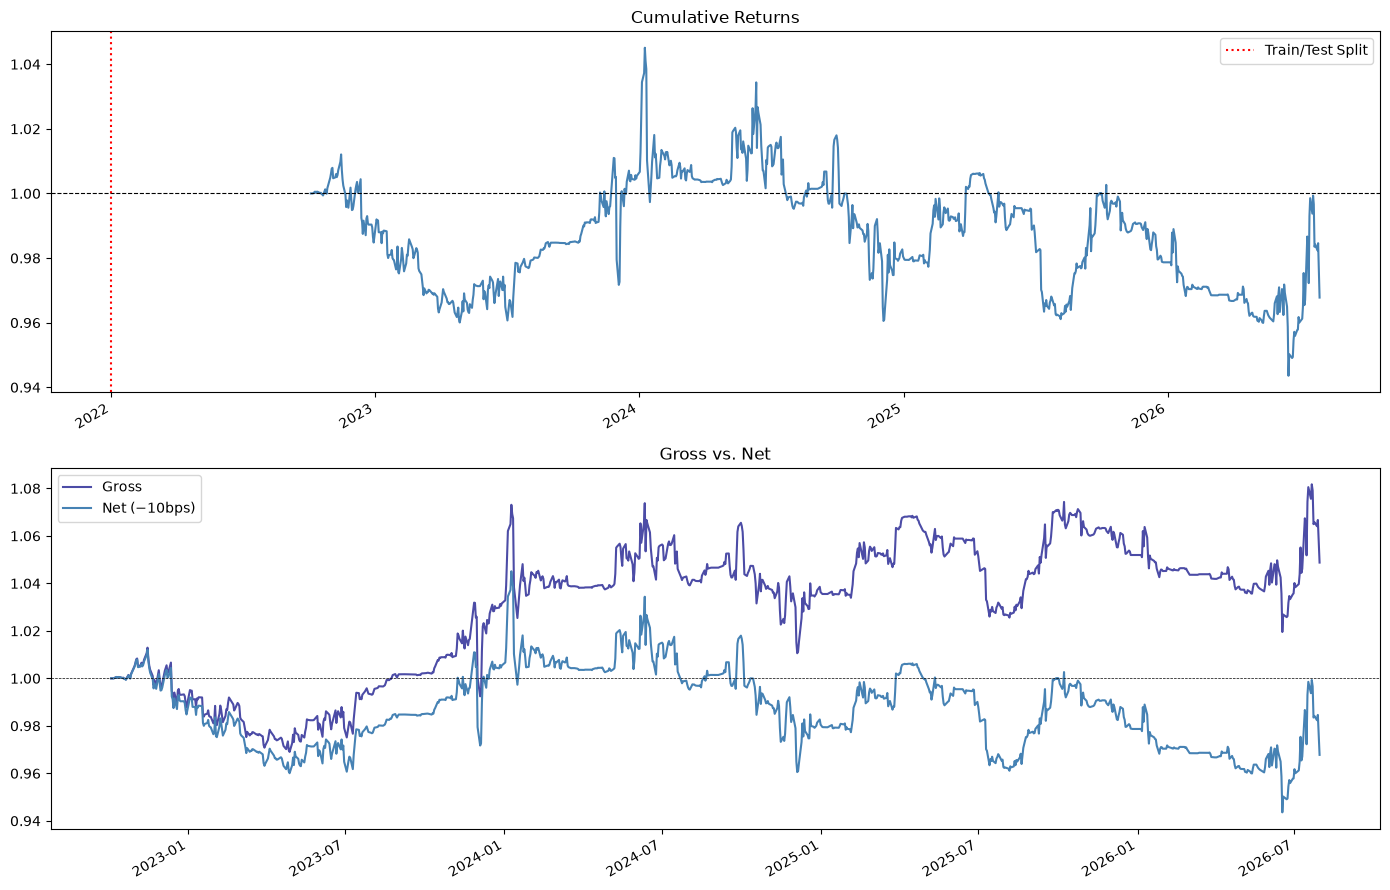

In [11]:
fig, axes = plt.subplots(2, 1, figsize = (14, 9))
(1 + net_returns).cumprod().plot(ax = axes[0], color = 'steelblue', linewidth = 1.5)
axes[0].axhline(1.0, color = 'black', linestyle = '--', linewidth = 0.8)

if 'dt' in globals() and hasattr(dt, 'test_start'):
    axes[0].axvline(pd.Timestamp(dt.test_start), color = 'red',
                    linestyle = ':', label = 'Train/Test Split')
title = "Cumulative Returns"
if 'perf' in globals():
    title += f" | Sharpe: {perf['sharpe_ratio']:.3f} | MDD: {perf['max_drawdown']:.1%}"
axes[0].set_title(title)
axes[0].legend()

(1 + trades['gross_return']).cumprod().plot(ax = axes[1], label = 'Gross', alpha = 0.7, color = 'navy')
(1 + trades['net_return']).cumprod().plot(ax = axes[1], label = 'Net (−10bps)', color = 'steelblue', linewidth = 1.5)
axes[1].axhline(1.0, color = 'black', linestyle = '--', linewidth = 0.5)
axes[1].legend()
axes[1].set_title("Gross vs. Net")

plt.tight_layout()
plt.show()

In [12]:
diag = bt.macro_regime_diagnostics(net_returns, macro_returns)
print("Sharpe by Macro Regime Quartile:")
print(diag.to_string())

Sharpe by Macro Regime Quartile:
          Q1     Q2     Q3     Q4
VIX    0.324  0.548 -0.534 -1.582
Brent -0.476  0.154  0.407 -1.288


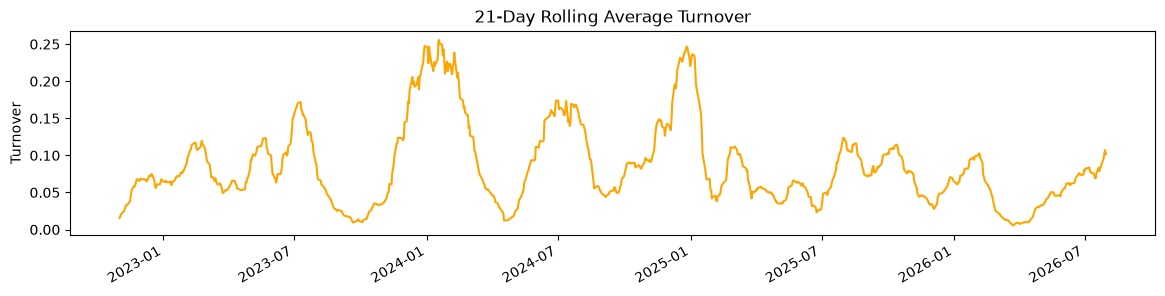

Avg daily turnover: 0.0842
Avg annual turnover: 21.23x


In [13]:
trades['turnover'].rolling(21).mean().plot(figsize = (14, 3), color = 'orange', title = "21-Day Rolling Average Turnover")
plt.ylabel("Turnover")
plt.show()
print(f"Avg daily turnover: {trades['turnover'].mean():.4f}")
print(f"Avg annual turnover: {trades['turnover'].mean()*252:.2f}x")

In [14]:
if 'perf' not in globals() or perf is None:
    perf = bt.compute_performance(net_returns, trades, macro_returns)
output_dir = Path("Outputs")
output_dir.mkdir(exist_ok = True)
net_returns.to_frame("net_return").to_csv(output_dir / "net_returns.csv")
perf.to_frame("strategy").to_csv(output_dir / "performance.csv")
positions.to_csv(output_dir / "signals.csv")
trades.to_csv(output_dir / "trades.csv")
print("Saved successfully.")
print(perf[['annualized_returns', 'sharpe_ratio', 'ann_turnover', 'max_drawdown']])

Saved successfully.
annualized_returns    -0.0069
sharpe_ratio          -0.1170
ann_turnover          21.2250
max_drawdown          -0.0971
dtype: float64


In [15]:
windows = [20, 30, 45, 60, 75, 90]
print(f"{'Window':>8} {'Sharpe':>8} {'Ann.Ret':>9} {'Turnover':>10} {'Active Days':>12}")
print("─" * 55)
for w in windows:
    z = md.compute_rolling_zscore(residuals, window = w).dropna()
    signals = bt.generate_signals(z, top_n = bt.top_n, exit_ = bt.exit_threshold, 
                                  min_hold = bt.min_hold_days, momentum = True)
    
    pc1 = md.compute_pc1_concentration(covs)
    positions_raw = bt.construct_portfolio(signals, zscores = z, residuals = residuals)
    positions = bt.apply_continuous_concentration_scaling(positions_raw, pc1)
    positions = bt.apply_macro_regime_filter(positions, macro_returns, vix_window = 90, brent_window = 90)
    
    net, trades = bt.compute_portfolio_returns(positions, stocks_returns)
    perf = bt.compute_performance(net, trades, macro_returns)
    
    print(f"{w:>7}d {perf['sharpe_ratio']:>8.3f} {perf['annualized_returns']:>9.2%} "
          f"{perf['ann_turnover']:>10.2f} {perf['active_days']:>12.0f}")

  Window   Sharpe   Ann.Ret   Turnover  Active Days
───────────────────────────────────────────────────────
     20d   -0.051    -0.32%      22.70          921
     30d   -0.449    -2.49%      22.80          909
     45d   -0.117    -0.69%      21.23          905
     60d   -0.408    -2.44%      21.56          910
     75d   -0.431    -2.61%      21.98          901
     90d   -0.288    -1.75%      21.37          895


In [16]:
# ========== TRADE DIAGNOSTIC ==========
print("=== Individual Trade Analysis ===")

# Get entry dates
entries = signals[signals != 0].stack()
entries = entries[entries != 0]

trade_log = []

for (date, ticker), direction in entries.items():
    # Residual at entry
    entry_z = zscores.loc[date, ticker]
    
    # Future residual returns (next 5 and 10 days)
    future_res = residuals[ticker].loc[date:].iloc[1:11]  # next 10 days
    
    if len(future_res) < 5:
        continue
        
    ret_5d = future_res.iloc[:5].sum()
    ret_10d = future_res.iloc[:10].sum()
    
    # Correct direction profit
    if direction > 0:      # Long residual
        pnl_5d = ret_5d
        pnl_10d = ret_10d
    else:                  # Short residual
        pnl_5d = -ret_5d
        pnl_10d = -ret_10d
    
    trade_log.append({
        'date': date,
        'ticker': ticker,
        'direction': 'Long' if direction > 0 else 'Short',
        'entry_z': round(entry_z, 2),
        'pnl_5d': round(pnl_5d, 4),
        'pnl_10d': round(pnl_10d, 4),
        'win_5d': pnl_5d > 0,
        'win_10d': pnl_10d > 0
    })

trade_df = pd.DataFrame(trade_log)

if len(trade_df) > 0:
    print(f"\nTotal entries analyzed: {len(trade_df)}")
    print(f"Win rate 5-day : {trade_df['win_5d'].mean():.1%}")
    print(f"Win rate 10-day: {trade_df['win_10d'].mean():.1%}")
    print(f"Avg PnL 5-day  : {trade_df['pnl_5d'].mean():.4f}")
    print(f"Avg PnL 10-day : {trade_df['pnl_10d'].mean():.4f}")
    
    print("\nBreakdown by direction:")
    print(trade_df.groupby('direction')[['pnl_5d', 'pnl_10d', 'win_5d', 'win_10d']].mean().round(4))
    
    # Show worst and best trades
    print("\nWorst 5 trades (10d):")
    display(trade_df.nsmallest(5, 'pnl_10d')[['date', 'ticker', 'direction', 'entry_z', 'pnl_10d']])
    
    print("\nBest 5 trades (10d):")
    display(trade_df.nlargest(5, 'pnl_10d')[['date', 'ticker', 'direction', 'entry_z', 'pnl_10d']])
else:
    print("No trades found to analyze.")

=== Individual Trade Analysis ===

Total entries analyzed: 18980
Win rate 5-day : 49.4%
Win rate 10-day: 49.3%
Avg PnL 5-day  : -0.0002
Avg PnL 10-day : -0.0004

Breakdown by direction:
           pnl_5d  pnl_10d  win_5d  win_10d
direction                                  
Long      -0.0001  -0.0003  0.4839   0.4816
Short     -0.0002  -0.0004  0.4949   0.4934

Worst 5 trades (10d):


,date,ticker,direction,entry_z,pnl_10d
12103,2025-03-07,LUV,Short,0.28,-0.2459
12083,2025-03-06,LUV,Short,1.23,-0.2292
12123,2025-03-10,LUV,Short,0.33,-0.2199
12063,2025-03-05,LUV,Short,-0.73,-0.2189
12043,2025-03-04,LUV,Short,-0.16,-0.1908



Best 5 trades (10d):


,date,ticker,direction,entry_z,pnl_10d
12423,2025-03-31,LUV,Short,0.34,0.2024
13963,2025-07-23,LUV,Short,-0.34,0.1754
12403,2025-03-28,LUV,Short,0.16,0.1698
12303,2025-03-21,LUV,Short,0.69,0.1656
13943,2025-07-22,LUV,Short,0.09,0.1645


In [17]:
print("=== MOMENTUM MODE TEST ===")

z = md.compute_rolling_zscore(residuals, window = 45).dropna()

signals_mom = bt.generate_signals(z, top_n = bt.top_n, exit_ = bt.exit_threshold, min_hold = bt.min_hold_days, momentum = True)
positions_raw = bt.construct_portfolio(signals_mom, zscores = z, residuals = residuals)
positions = bt.apply_continuous_concentration_scaling(positions_raw, pc1)
positions = bt.apply_macro_regime_filter(positions, macro_returns, vix_window = 90, brent_window = 90)
net_mom, trades_mom = bt.compute_portfolio_returns(positions, stocks_returns)
perf_mom = bt.compute_performance(net_mom, trades_mom, macro_returns)
print(perf_mom[['annualized_returns', 'sharpe_ratio', 'ann_turnover', 'max_drawdown', 'hit_rate']])

=== MOMENTUM MODE TEST ===
annualized_returns    -0.0069
sharpe_ratio          -0.1170
ann_turnover          21.2250
max_drawdown          -0.0971
hit_rate               0.4663
dtype: float64
